In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('../data/QueryResults.csv')

In [4]:
df.head(2)

,m,TagName,Unnamed: 2
0,2008-07-01 00:00:00,c#,3
1,2008-08-01 00:00:00,assembly,8


**Total Number Of Post**

In [5]:
df.groupby('TagName').sum('Unnamed: 2').sort_values('Unnamed: 2', ascending=False).head(2)

,Unnamed: 2
TagName,
javascript,2056510
java,1696403


**Data Cleaning**

Date

In [6]:
df.m = pd.to_datetime(df.m)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1991 entries, 0 to 1990
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   m           1991 non-null   datetime64[ns]
 1   TagName     1991 non-null   object        
 2   Unnamed: 2  1991 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 46.8+ KB


**Data Manipulation**

Reshape

In [7]:
reshaped_df = df.pivot(index='m', columns='TagName', values='Unnamed: 2')
reshaped_df.head(2)

TagName,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
m,,,,,,,,,,,,,,
2008-07-01,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-08-01,8.0,85.0,511.0,164.0,14.0,NaN,222.0,162.0,28.0,161.0,124.0,NaN,73.0,NaN


**Matplot Library**

In [8]:
import matplotlib.pyplot as plt

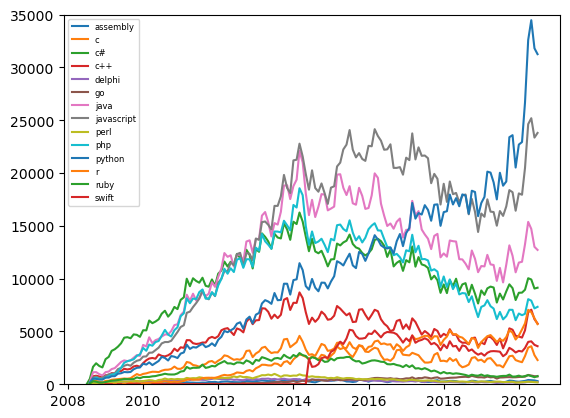

In [9]:
plt.ylim(0, 35000)
for column in reshaped_df:
    plt.plot(reshaped_df.index, reshaped_df[column], label=reshaped_df[column].name)
plt.legend(fontsize=6)

**Rolling Date**

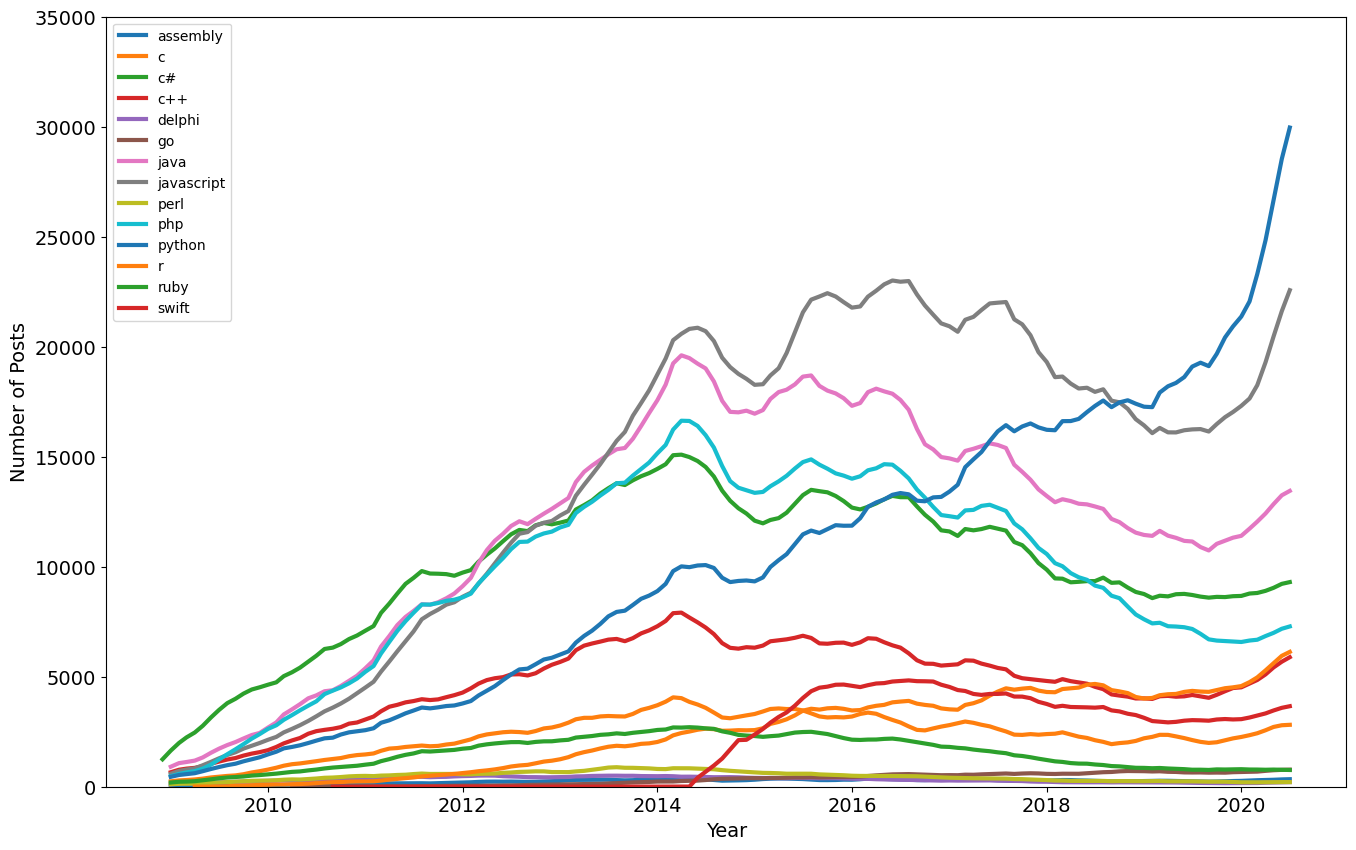

In [17]:
roll_df = reshaped_df.rolling(window=6).mean()

plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 35000)

for column in roll_df.columns:
    plt.plot(roll_df.index, roll_df[column], linewidth=3, label=roll_df[column].name)

plt.legend(fontsize=10)